In [52]:
import numpy as np
import cv2 as cv

import matplotlib.pyplot as plt

import rembg

from os.path import dirname, join, abspath

## Version REMBG

In [53]:
BASE_DIR = 'Samples'

input_path  = join(BASE_DIR, '01_Samples', '00_state', '01_raton.jpeg')
output_path = join(BASE_DIR, '01_Samples', '01_state', '01_raton.png')

input_img = cv.imread(input_path)
output_img = rembg.remove(input_img) # Hace magia con IA

cv.imwrite(output_path, output_img)


True

## Versión Propia

In [54]:
def clean_image(img_color, threshold_value=150, se_size=(55, 55)):
    """
    Limpia una imagen a color de su fondo mediante umbralización y operaciones morfológicas.
    
    Args:
        img_color: Imagen en color (BGR)
        threshold_value: Valor de umbral para binarización (default: 140)
        se_size: Tamaño del elemento estructurante (default: (35, 35))
    
    Returns:
        Imagen limpia con canal alfa (BGRA)
    """
    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    img_gray = cv.medianBlur(img_gray, 5)

    img_gray_log = cv.convertScaleAbs(np.log1p(np.array(img_gray, dtype="float")) * 30)

    _, bin = cv.threshold(img_gray_log, threshold_value, 255, cv.THRESH_BINARY)

    bin_open = cv.dilate(bin, cv.getStructuringElement(cv.MORPH_CROSS, se_size))

    # Crear imagen BGRA con canal alfa
    img_bgra = cv.cvtColor(img_color, cv.COLOR_BGR2BGRA)
    img_bgra[:, :, 3] = bin_open  # Asignar la máscara al canal alfa
    
    return img_bgra

### Test con el ejemplo 01, el ratón

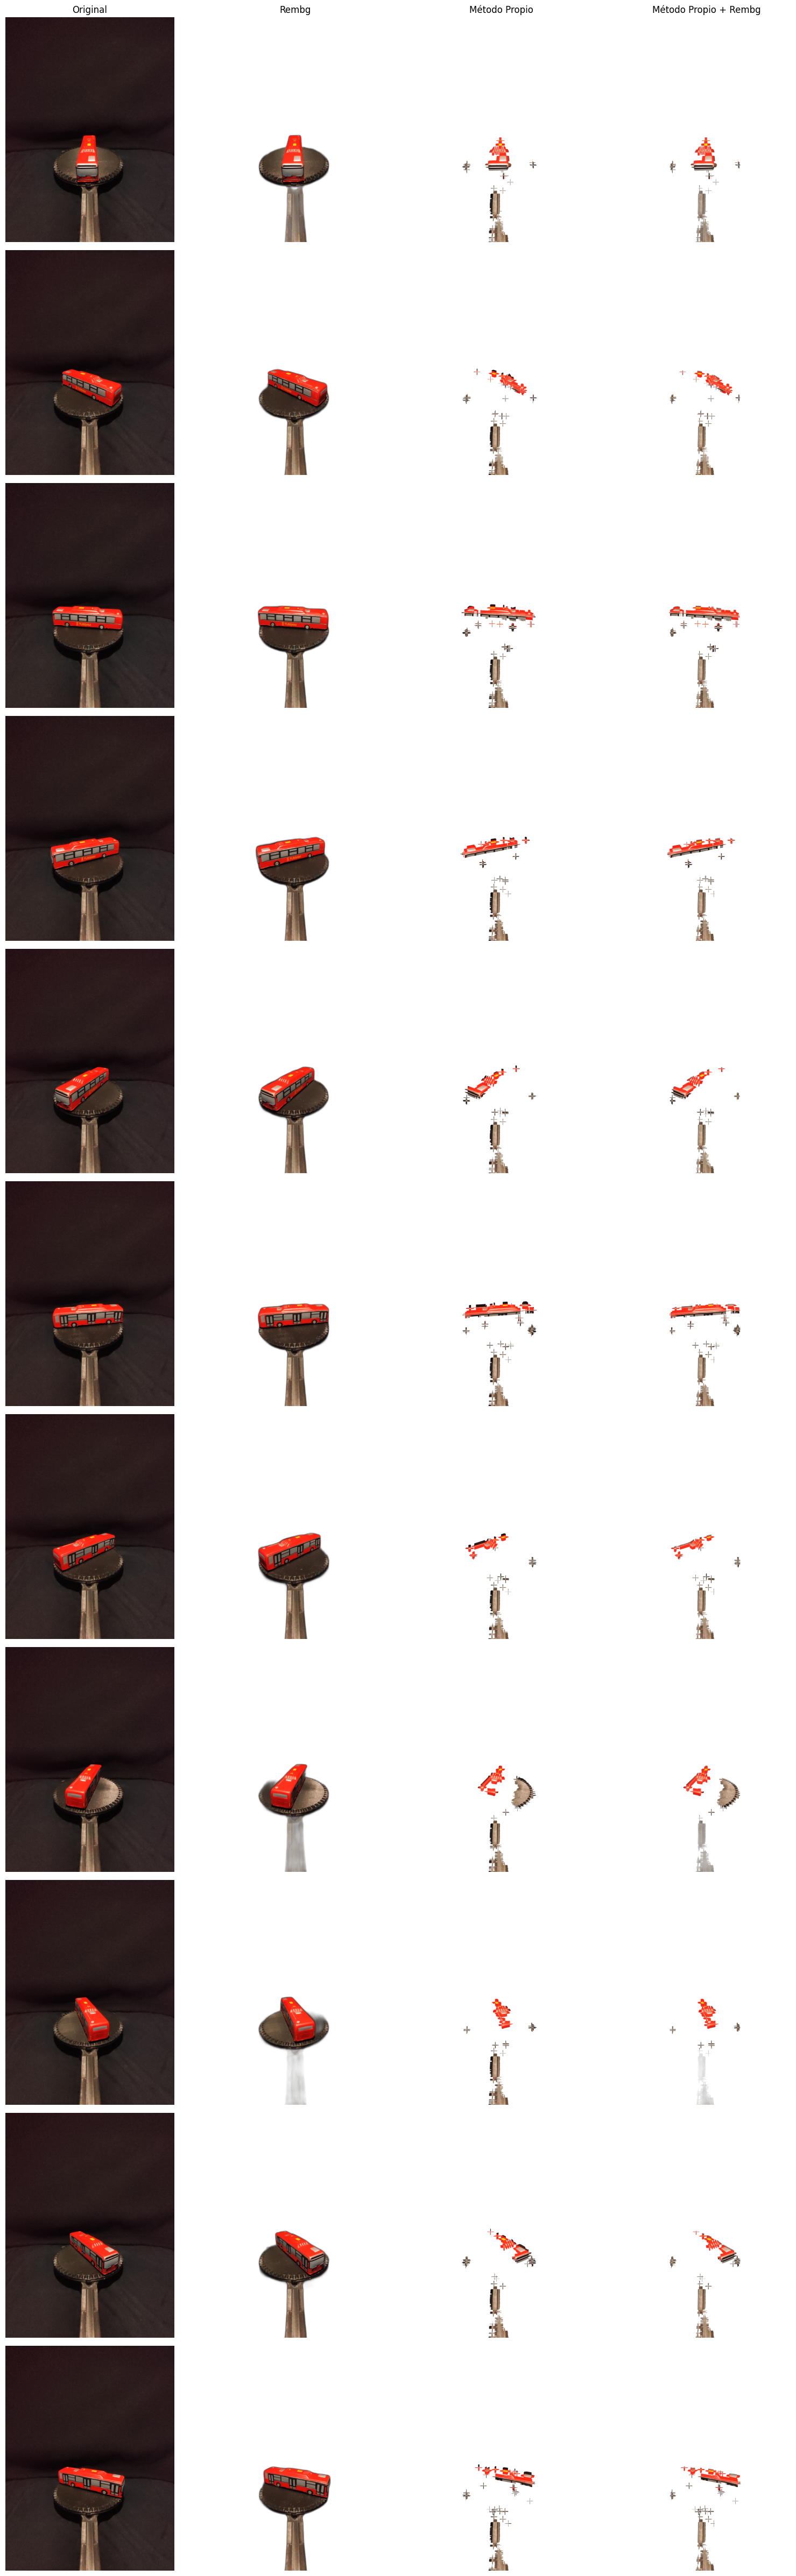

In [55]:
# Leer las 3 primeras imágenes del modelo
img_paths = [
    join(BASE_DIR, '02_Samples', '00_state', f'{i:02d}_model.jpeg')
    for i in range(1, 12)
]

imgs_original = [cv.imread(path) for path in img_paths]

# Procesar las imágenes
imgs_rembg = [rembg.remove(img) for img in imgs_original]
imgs_custom = [clean_image(img) for img in imgs_original]
imgs_custom_rembg = [rembg.remove(img) for img in imgs_custom]

# Crear la grid de visualización
fig, axes = plt.subplots(11, 4, figsize=(16, 48))

titles = ['Original', 'Rembg', 'Método Propio', 'Método Propio + Rembg']

for row in range(11):
    # Original
    axes[row, 0].imshow(cv.cvtColor(imgs_original[row], cv.COLOR_BGR2RGB))
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title(titles[0])
    
    # Rembg
    axes[row, 1].imshow(cv.cvtColor(imgs_rembg[row], cv.COLOR_BGRA2RGBA))
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].set_title(titles[1])
    
    # Método propio
    axes[row, 2].imshow(cv.cvtColor(imgs_custom[row], cv.COLOR_BGRA2RGBA))
    axes[row, 2].axis('off')
    if row == 0:
        axes[row, 2].set_title(titles[2])
    
    # Método propio + Rembg
    axes[row, 3].imshow(cv.cvtColor(imgs_custom_rembg[row], cv.COLOR_BGRA2RGBA))
    axes[row, 3].axis('off')
    if row == 0:
        axes[row, 3].set_title(titles[3])

plt.tight_layout()
plt.show()

### Probamos diferentes tamaños de elemento estructurante


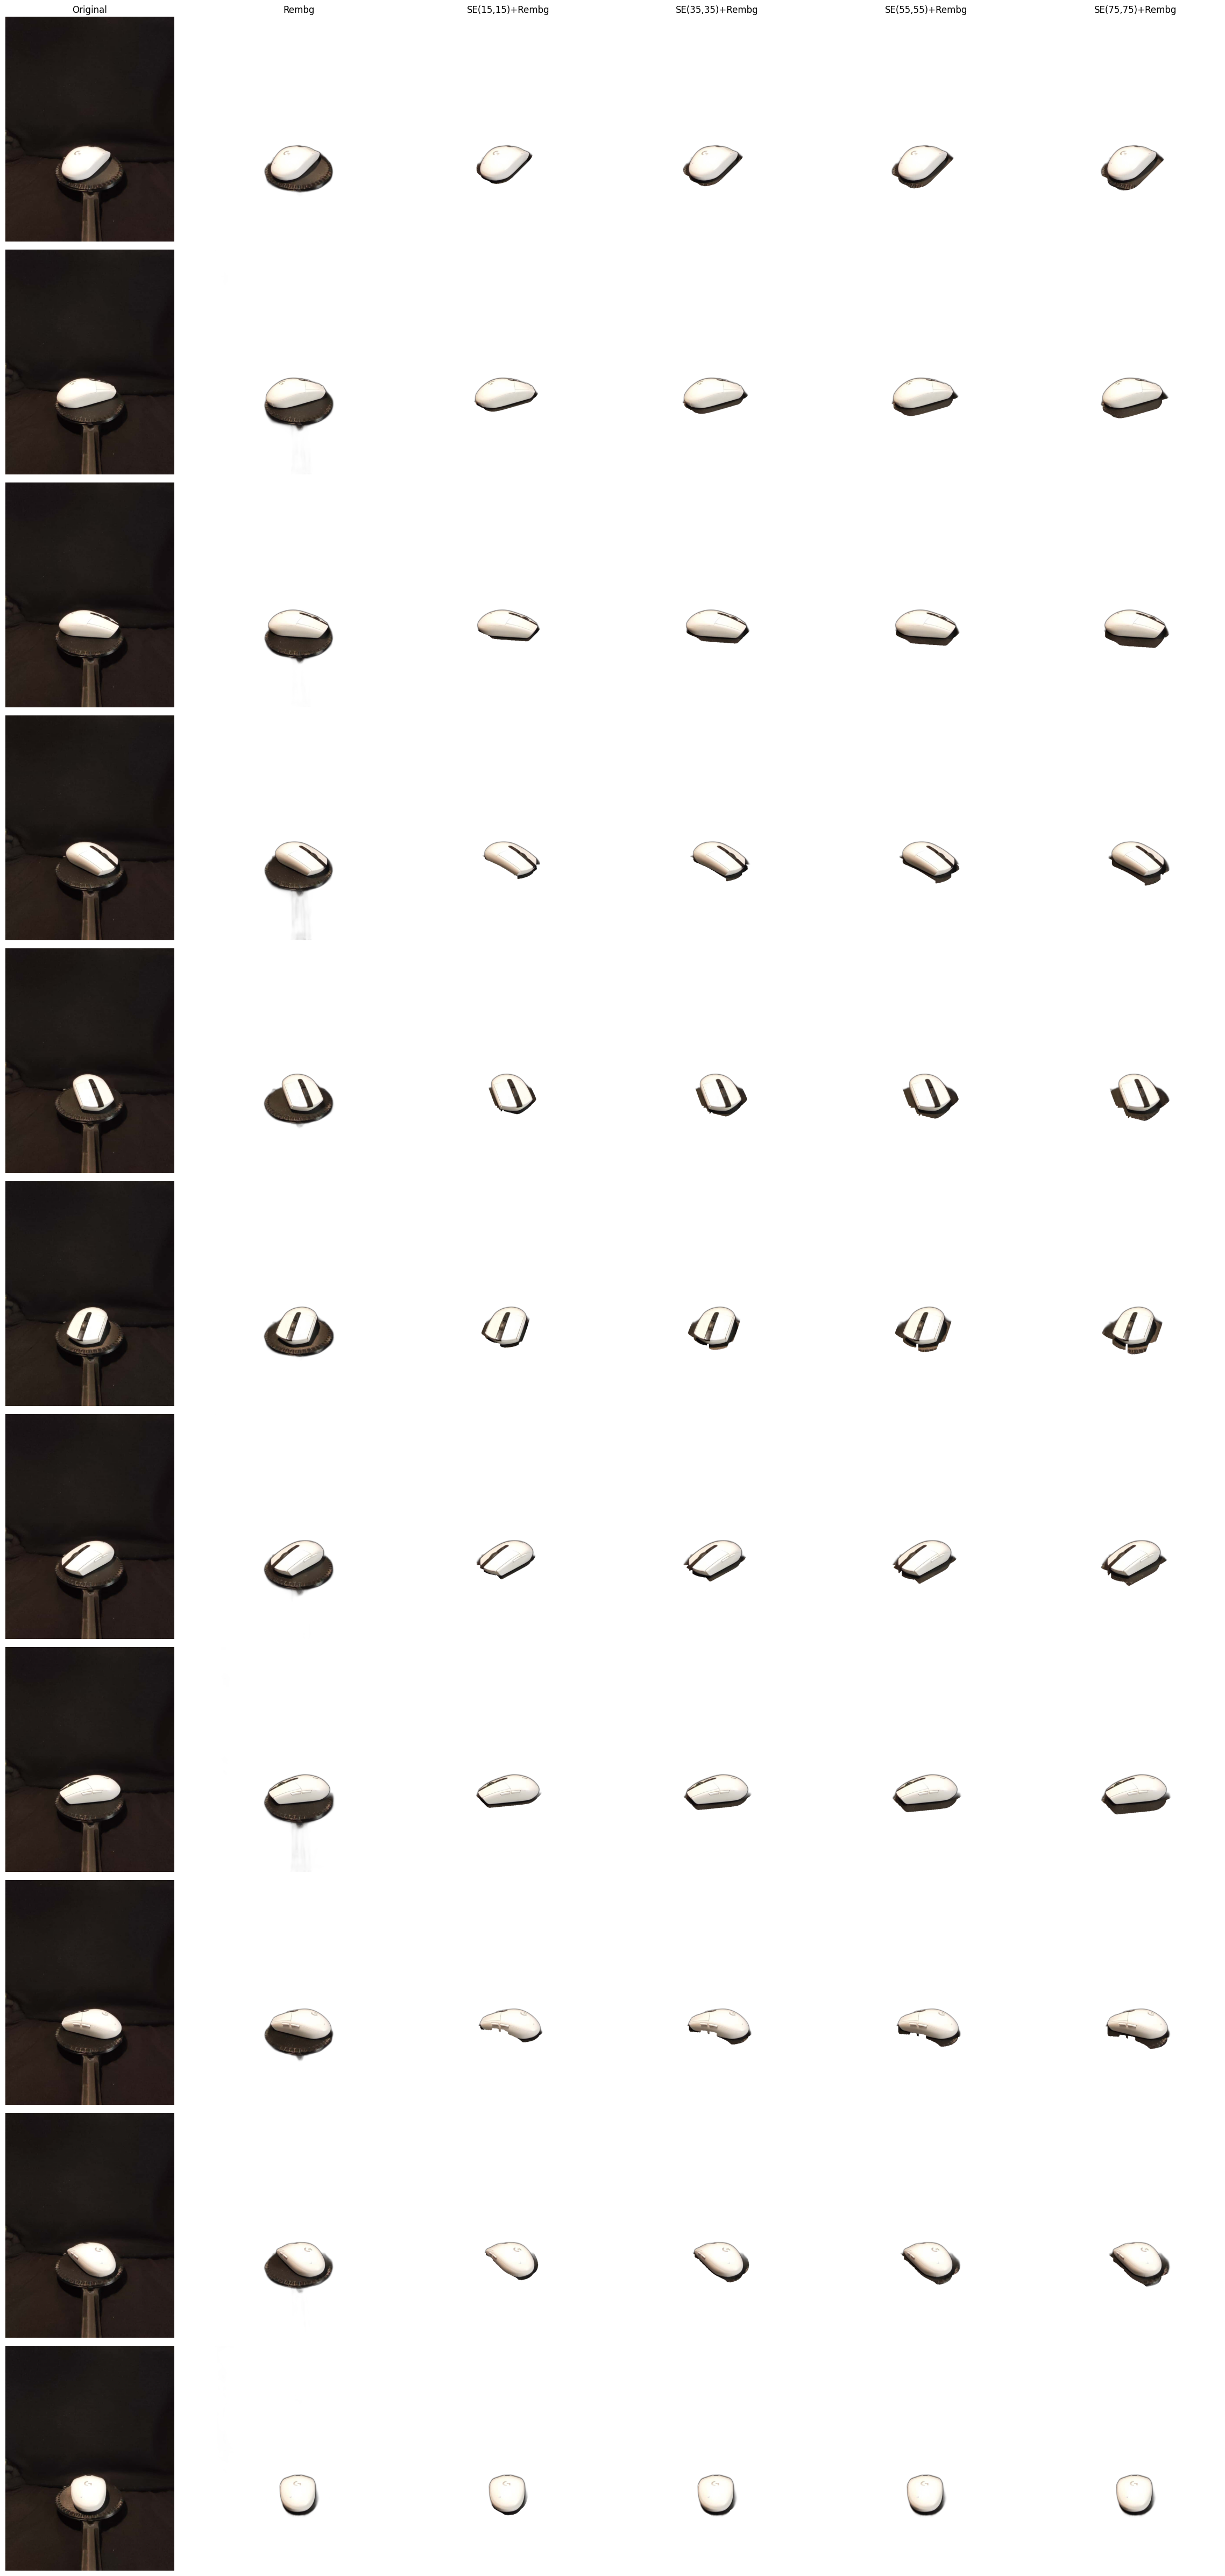

In [56]:
# Leer las 3 primeras imágenes del ratón
img_paths = [
    join(BASE_DIR, '01_Samples', '00_state', f'{i:02d}_raton.jpeg')
    for i in range(1, 12)
]

imgs_original = [cv.imread(path) for path in img_paths]

# Definir tamaños de SE a probar
se_sizes = [(35, 35), (55, 55), (75, 75), (95, 95)]

# Procesar las imágenes con diferentes tamaños de SE
imgs_rembg = [rembg.remove(img) for img in imgs_original]
imgs_custom_by_se = {
    se_size: [clean_image(img, se_size=se_size) for img in imgs_original]
    for se_size in se_sizes
}
imgs_custom_rembg_by_se = {
    se_size: [rembg.remove(img) for img in imgs_custom_by_se[se_size]]
    for se_size in se_sizes
}

# Crear la grid de visualización (11 filas x 6 columnas)
fig, axes = plt.subplots(11, 6, figsize=(24, 48))

titles = ['Original', 'Rembg', 'SE(15,15)+Rembg', 'SE(35,35)+Rembg', 'SE(55,55)+Rembg', 'SE(75,75)+Rembg']

for row in range(11):
    # Original
    axes[row, 0].imshow(cv.cvtColor(imgs_original[row], cv.COLOR_BGR2RGB))
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title(titles[0])
    
    # Rembg solo
    axes[row, 1].imshow(cv.cvtColor(imgs_rembg[row], cv.COLOR_BGRA2RGBA))
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].set_title(titles[1])
    
    # Método propio + Rembg con diferentes SE
    for col, se_size in enumerate(se_sizes, start=2):
        axes[row, col].imshow(cv.cvtColor(imgs_custom_rembg_by_se[se_size][row], cv.COLOR_BGRA2RGBA))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(titles[col])

plt.tight_layout()
plt.show()

In [57]:
### Nuevo método de limpieza de imagen

In [58]:
def clean_image_v2(img_color, adaptive_block_size=11, adaptive_c=2, blur_sigma=3):
    """
    Limpia una imagen a color de su fondo usando umbralización adaptativa y refinamiento de bordes.
    
    Args:
        img_color: Imagen en color (BGR).
        adaptive_block_size: Tamaño de la vecindad para umbralización adaptativa (debe ser impar).
        adaptive_c: Constante restada al umbral medio/gaussiano.
        blur_sigma: Desviación estándar para el suavizado gaussiano de la máscara (refinamiento de borde).
        close_kernel_size: Tamaño del kernel para la operación de cierre morfológico (para rellenar pequeños agujeros).
    
    Returns:
        Imagen limpia con canal alfa (BGRA).
    """
    # 1. Preprocesamiento
    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
    
    # Aplicar Desenfoque de Mediana para reducir el ruido antes de la umbralización
    img_gray_blur = cv.medianBlur(img_gray, 5)

    # 2. Creación de la Máscara Binaria con Umbral Adaptativo
    bin_mask = cv.adaptiveThreshold(
        img_gray_blur, 
        255, 
        cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv.THRESH_BINARY_INV, # Usamos INVERSE para que el objeto sea blanco (255) y el fondo negro (0)
        adaptive_block_size, 
        adaptive_c
    )

    # 4. Refinamiento de Borde (Suavizado Gaussiano)
    # Esto transforma el borde duro (0 ó 255) en una transición suave,
    # eliminando el efecto de borde dentado y el contorno negro.
    # La imagen debe ser flotante para el desenfoque
    mask_float = bin_mask.astype(np.float32)
    
    # Aplicar Desenfoque Gaussiano. sigmaX y sigmaY definen la suavidad del borde.
    mask_soft = cv.GaussianBlur(mask_float, (3, 3), sigmaX=blur_sigma, sigmaY=blur_sigma)
    
    # Normalizar de nuevo a 0-255 y convertir a uint8
    mask_alpha = cv.normalize(mask_soft, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    # 5. Aplicar la Máscara al Canal Alfa
    img_bgra = cv.cvtColor(img_color, cv.COLOR_BGR2BGRA)
    
    # Asignar la máscara refinada al canal alfa
    img_bgra[:, :, 3] = mask_alpha
    
    return img_bgra

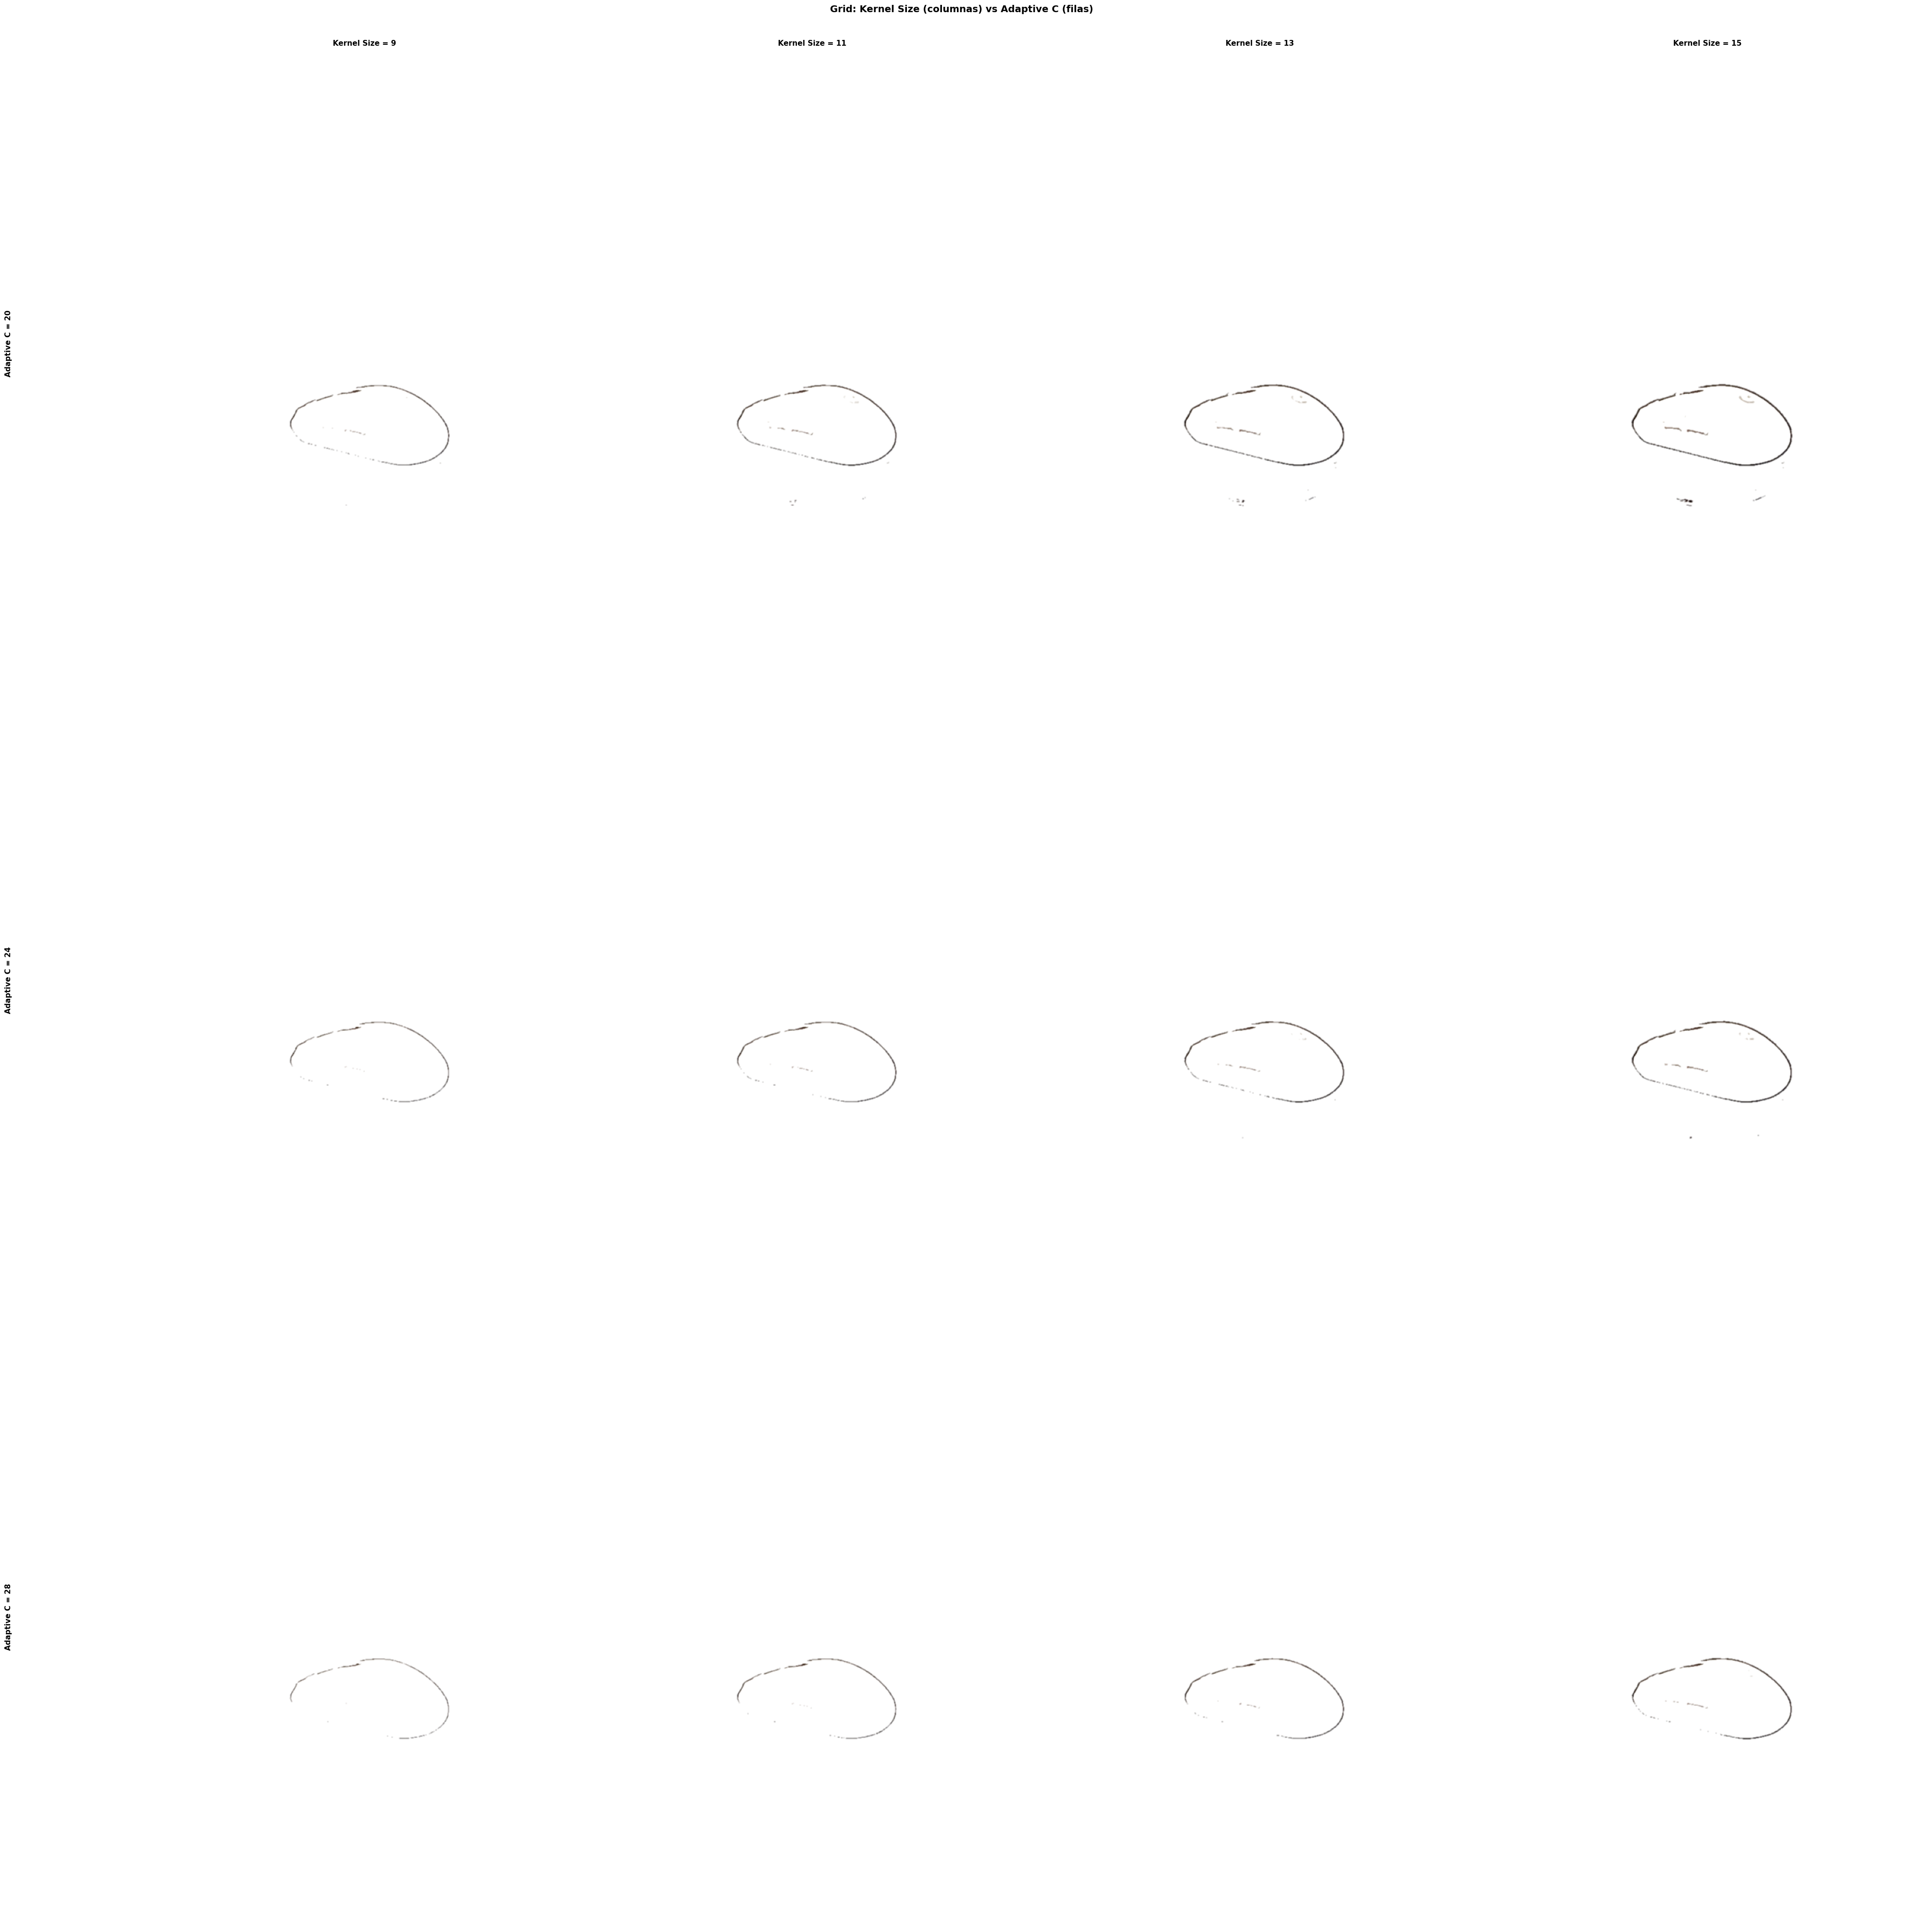

In [ ]:
# Leer solo la primera imagen del ratón
img_path = join(BASE_DIR, '02_Samples', '00_state', '01_model.jpeg')
img_original = cv.imread(img_path)

# Definir parámetros a probar
kernel_sizes = [9, 11, 13, 15]
adaptive_c_values = [20, 24, 28]

# Procesar la imagen con todas las combinaciones
imgs_grid = {}
for c_val in adaptive_c_values:
    for k_size in kernel_sizes:
        imgs_grid[(c_val, k_size)] = clean_image_v2(
            img_original, 
            adaptive_block_size=k_size, 
            adaptive_c=c_val
        )

# Crear la grid de visualización (3 filas x 4 columnas)
fig, axes = plt.subplots(3, 4, figsize=(40, 40))

# Configurar títulos y visualizar
for row, c_val in enumerate(adaptive_c_values):
    for col, k_size in enumerate(kernel_sizes):
        axes[row, col].imshow(cv.cvtColor(imgs_grid[(c_val, k_size)], cv.COLOR_BGRA2RGBA))
        axes[row, col].axis('off')
        
        # Título de columna (kernel_size)
        if row == 0:
            axes[row, col].set_title(f'Kernel Size = {k_size}', fontsize=11, fontweight='bold')
        
        # Etiqueta de fila (adaptive_c) - a la izquierda
        if col == 0:
            axes[row, col].text(-0.3, 0.5, f'Adaptive C = {c_val}', 
                              transform=axes[row, col].transAxes,
                              fontsize=11, fontweight='bold',
                              va='center', ha='right', rotation=90)

plt.suptitle('Grid: Kernel Size (columnas) vs Adaptive C (filas)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(left=0.08)  # Ajustar margen izquierdo para las etiquetas
plt.show()

In [60]:
def feature_and_matching_knn_test(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.knnMatch(des1, des2, k=2)
  #Escogemos sólo las asociaciones de puntos cercanos
  good_matches = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)

  #Medimos rendimiento
  img_matched = cv.drawMatchesKnn(im1, kp1, im2, kp2, good_matches, None, matchColor=(0, 255, 0),
                       singlePointColor=(0, 255, 0), flags=2)
  plt.imshow(img_matched)
  plt.axis('off')
  print(f"Puntos encontrados img1: {len(kp1)}")
  print(f"Puntos encontrados img2: {len(kp2)}")
  print(f"Buenos emparejamientos (Matches): {len(good_matches)}")


In [61]:
def feature_and_matching(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.match(des1, des2)
  #Escogemos sólo las asociaciones de puntos cercanos
  '''  
  matches = bf.knnmatch(des1, des2)
  good_matches = []
  pts1 = []
  pts2 = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)
      pts1.append(kp1[m.queryIdx].pt)
      pts2.append(kp2[m.trainIdx].pt)
  '''
  return (kp1, kp2[[p.trainIdx for p in matches]])


In [62]:
for i,j in zip(range(10),range(1,11)):
  print(f'Caso {i},{j}')
  feature_and_matching_knn_test(imgs_clean[i], imgs_clean[j])


Caso 0,1


NameError: name 'imgs_clean' is not defined

In [ ]:
def Sfm(pts1, pts2):
    K 

    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.999, threshold=1.0)